# Загрузка данных

In [1]:
import logging
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

log_file = logging.FileHandler('recommendations.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logging.basicConfig(handlers=(log_file, console_out), level=logging.INFO)

Если необходимо, то загружаем items.parquet, events.parquet.

In [4]:
items = pd.read_parquet('../data/items.parquet')
events = pd.read_parquet('../data/events.parquet')

In [5]:
import sklearn.preprocessing

# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events['user_id'])
events['user_id_enc'] = user_encoder.transform(events['user_id'])

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items['item_id'])
items['item_id_enc'] = item_encoder.transform(items['item_id'])
events['item_id_enc'] = item_encoder.transform(events['item_id'])

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [10]:
train_split_date = pd.to_datetime('2022-12-16').to_datetime64()

train_split_date_idx = events['started_at'] < train_split_date

events_train = events[train_split_date_idx]
events_test = events[~train_split_date_idx]

events_train.shape, events_test.shape

((9110491, 10), (3912838, 10))

In [21]:
# количество пользователей в train и test
users_train = events_train['user_id'].drop_duplicates()
users_test = events_test['user_id'].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = set(users_train) & set(users_test)

len(users_train), len(users_test), len(common_users)

(1113710, 702781, 456576)

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

In [6]:
# import scipy
# import sklearn.preprocessing

# # перекодируем идентификаторы пользователей: 
# # из имеющихся в последовательность 0, 1, 2, ...
# user_encoder = sklearn.preprocessing.LabelEncoder()
# user_encoder.fit(events['user_id'])
# events_train['user_id_enc'] = user_encoder.transform(events_train['user_id'])
# events_test['user_id_enc'] = user_encoder.transform(events_test['user_id'])

# # перекодируем идентификаторы объектов: 
# # из имеющихся в последовательность 0, 1, 2, ...
# item_encoder = sklearn.preprocessing.LabelEncoder()
# item_encoder.fit(items['item_id'])
# items['item_id_enc'] = item_encoder.transform(items['item_id'])
# events_train['item_id_enc'] = item_encoder.transform(events_train['item_id'])
# events_test['item_id_enc'] = item_encoder.transform(events_test['item_id'])

In [22]:
import scipy

# создаём sparse-матрицу формата CSR 
user_item_matrix_train = scipy.sparse.csr_matrix((
    events_train['rating'],
    (events_train['user_id_enc'], events_train['item_id_enc'])),
    dtype=np.int8) 

In [23]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(factors=10, iterations=10, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train) 

/home/mle-user/mle_projects/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle_projects/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [00:30<00:00,  3.08s/it]


In [24]:
user_item_matrix_train.shape, len(user_encoder.classes_)

((1359913, 39847), 1359915)

In [1]:
user_encoder.classes_

NameError: name 'user_encoder' is not defined

In [25]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(user_item_matrix_train.shape[0])
# user_ids_encoded = range(len(user_encoder.classes_))
# получаем рекомендации для всех пользователей
als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False,
    N=10) 

In [26]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    'user_id_enc': user_ids_encoded,
    'item_id_enc': item_ids_enc.tolist(), 
    'score': als_scores.tolist()})
als_recommendations = als_recommendations.explode(['item_id_enc', 'score'], ignore_index=True)

# приводим типы данных
als_recommendations['item_id_enc'] = als_recommendations['item_id_enc'].astype('int')
als_recommendations['score'] = als_recommendations['score'].astype('float')

# получаем изначальные идентификаторы
als_recommendations['user_id'] = user_encoder.inverse_transform(als_recommendations['user_id_enc'])
als_recommendations['item_id'] = item_encoder.inverse_transform(als_recommendations['item_id_enc'])
als_recommendations = als_recommendations.drop(columns=['user_id_enc', 'item_id_enc']) 

In [27]:
als_recommendations.sample(8).T

,6047141,4087522,3592495,5502562,12879469,5341139,11914683,11104091
score,4.873826e-01,5.221176e-01,2.115531e-02,0.0,4.089803e-02,4.680017e-03,3.184676e-02,2.452453e-01
user_id,6.112190e+05,4.131130e+05,3.631070e+05,556151.0,1.301820e+06,5.398300e+05,1.204342e+06,1.122388e+06
item_id,9.890175e+07,4.418412e+07,2.572719e+07,861.0,6.548435e+07,1.838578e+07,7.882420e+07,5.483742e+07


In [29]:
# Сохраним результат
als_recommendations.to_parquet('../data/personal_als.parquet') 

Анализ результатов

In [30]:
als_recommendations.shape

(13599130, 3)

array([[<Axes: title={'center': 'score'}>]], dtype=object)

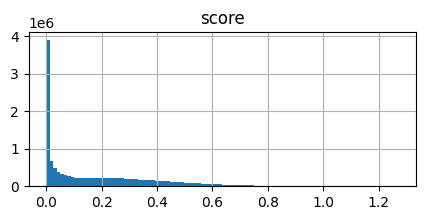

In [31]:
als_recommendations[['score']].hist(bins=100, figsize=(5, 2))

In [33]:
als_recommendations = (
    als_recommendations
    .merge(events[['user_id', 'item_id', 'rating']]
    .rename(columns={'rating': 'rating_test'}), 
    on=['user_id', 'item_id'], how='left')
) 

In [34]:
als_recommendations.query('~rating_test.isnull()').sample(8)

,score,user_id,item_id,rating_test
12122390,0.503989,1225349,73376988,8.63
2801309,0.282562,283100,68938482,8.24
12970090,0.453362,1310993,93390818,8.06
1367332,0.190633,138180,50684233,8.51
12694980,0.251527,1283195,10776533,8.24
7324765,0.093997,740360,44034005,8.07
9911259,0.088470,1001792,93556497,6.53
13310499,0.487650,1345392,44625560,8.13


Проверка метрик на адекватность

In [35]:
import sklearn.metrics

def compute_ndcg(rating: pd.Series, score: pd.Series, k):

    ''' подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    '''
    
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(np.asarray([rating.to_numpy()]), np.asarray([score.to_numpy()]), k=k)

    return ndcg 

In [36]:
ndcg_at_5_scores = als_recommendations.query('~rating_test.isnull()') \
    .groupby('user_id').apply(lambda x: compute_ndcg(x['rating_test'], x['score'], k=5)) 

In [37]:
logging.info(f'personal_als NDCG@5: {ndcg_at_5_scores.mean()}') 

personal_als NDCG@5: 0.997311827764771


In [5]:
import scipy
import numpy as np

row = np.array([0, 1, 2, 10])
col = np.array([0, 1, 1, 0])
data = np.array([1, 2, 4, 8])
scipy.sparse.csr_matrix((data, (row, col))).toarray()


array([[1, 0],
       [0, 2],
       [0, 4],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [8, 0]])